<a href="https://colab.research.google.com/github/IrynaSukhoverkhova/my-first-work-place/blob/main/Additional_hw_6_Pandas_%2B_Viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Усі імпорти рекомендую розташувати отут зверху для зручності.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1.Завантажте дані у pandas dataframe з файла `ecommerce_data.csv`. Обовʼязково при завантаженні вкажіть параметр `encoding = 'ISO-8859-1'`, без нього буде помилка.

In [18]:
df = pd.read_csv(
    r'/content/ecommerce_data_1.csv', encoding='ISO-8859-1'
)

2.Виведіть перші три записи в завантаженому наборі даних

In [19]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


3.Перейменуйте колонки, для цього просто запустіть код нижче та зверніть увагу, як ми перейменували колонки. Перейменування тут - просто для зручності.

In [20]:
df = df.rename(columns={
    'InvoiceNo': 'invoiceno',
    'StockCode': 'stockcode',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoicedate',
    'UnitPrice': 'unitprice',
    'CustomerID': 'custid',
    'Country': 'country'
})

4.Виведіть поточні назви колонок.

In [21]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'custid', 'country'],
      dtype='object')

# Базове розуміння даних

5.Виведіть кількість колонок і стовпців в наборі даних.

In [22]:
df.shape
print(f"Кількість рядків: {df.shape[0]}, кількість стовпців: {df.shape[1]}")

Кількість рядків: 541909, кількість стовпців: 8


6.Виведіть типи даних в кожній з колонок. Будь-яким способом, але аби для Вас як для дослідника стало зрозуміло, з якими даними ми зараз маємо справу.

In [23]:
df.dtypes

,0
invoiceno,object
stockcode,object
description,object
quantity,int64
invoicedate,object
unitprice,float64
custid,float64
country,object


7.Виведіть кількість пустих (null) значень в кожній з колонок за спаданням цієї кількості.

In [24]:
df.isnull().sum().sort_values(ascending=False)

,0
custid,135080
description,1454
stockcode,0
invoiceno,0
quantity,0
invoicedate,0
unitprice,0
country,0


### Конвертація дат

8.Конвертуйте дату колонки `invoicedate` у тип `datetime64[ns]`.

In [25]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

Запустіть код нижче:

In [26]:
df.invoicedate[:2]

,invoicedate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00


# Чистка даних

### Прибираємо пусті значення (NA)

9.Приберіть усі пусті значення з набору даних `df` і запишіть результат у нову змінну `df_new`.

In [27]:
df_new = df.dropna()

10.Виведіть кількість колонок і рядків в `df_new`.

In [29]:
df_new.shape
print(f"Кількість рядків: {df_new.shape[0]}, кількість стовпців: {df_new.shape[1]}")

Кількість рядків: 406829, кількість стовпців: 8


11.Виведіть, який відсоток (від 0 до 100%) рядків ми видалили з `df`, коли прибрали пусті значення? Округліть результат до цілих відсотків.

In [30]:
deleted_pct = round((1 - len(df_new) / len(df)) * 100)
print(f"{deleted_pct}%")

25%


Очікуваний результат: `25%`

### Приберемо негативні значення `quantity`

12.Виведіть мінімальне, максимальне і середнє значення колонки `quantity`. Найкраще згадати, як це зробити одною командою, що дозволяє "описати" колонки в датафреймі :)

In [31]:
df_new['quantity'].describe()

,quantity
count,406829.000000
mean,12.061303
std,248.693370
min,-80995.000000
25%,2.000000
50%,5.000000
75%,12.000000
max,80995.000000


13.Скажімо, нас не цікавлять записи з негативними quantity (бо це поверненння).   
Приберіть всі рядки, де `quantity` менше 0 з набора даних `df_new` і запишіть в той самий набір даних `df_new`.

In [32]:
df_new = df_new[df_new['quantity'] >= 0]

# Обробка даних

### Зміна типу даних `custid`

14.Ідентифікатор клієнта має мати тип "рядок" для простоти роботи з цією колонкою. Бо інакше пандас буде інтерпретувати цю колонку як число - а це логічно не правильно.
Перетворіть тип даних колонки `custid`  спочатку на int, а потім на рядок. Або можете зробити ці перетворення в одній функції (лямбді).

In [33]:
df_new['custid'] = df_new['custid'].astype(int).astype(str)

Запустіть код нижче:

In [34]:
df_new['custid'][:3]

,custid
0,17850
1,17850
2,17850


### Додамо колонку `amountspent`

15.Додайте в `df_new` колонку `amountspent`, яка є добутком колонок `quantity` і `unitprice`.

In [35]:
df_new['amountspent'] = df_new['quantity'] * df_new['unitprice']

### Додавання колонок `month`, `day`, `hour`, `yearmonth` для інвойса.

16.Використовуючи колонку invoicedate та те, що вона в нас вже має тип datetime, створіть 4 нових колонки в даних:
- `yearmonth` - рік і місяць інвойсу разом у форматі "2010-12" - тобто 12 місяць 2010го року і тип цієї колонки має бути датою (підказка: просто робимо для колонки`invoicedate` `dt.to_period('M')` для того аби таке отримати)
- `month` - місяць інвойсу
- `day` - день тижня інвойсу (понеділок - це перший, неділя - останній)
- `hour` - година інвойсу

Зробіть також так, аби `yearmonth` була третьою (за рахунком) колонкою в датафреймі, `month` - четвертою, `day` - пʼятою, `hour` - шостою.

In [36]:
# 1. Створюємо значення для нових колонок
yearmonth = df_new['invoicedate'].dt.to_period('M')
month = df_new['invoicedate'].dt.month
day = (
    df_new['invoicedate'].dt.dayofweek + 1
)  # dt.dayofweek дає 0 для понеділка, тому +1 (1 - понеділок, 7 - неділя)
hour = df_new['invoicedate'].dt.hour

# 2. Вставляємо колонки у потрібному порядку (починаючи з індексу 2 для третьої позиції)
df_new.insert(2, 'yearmonth', yearmonth)
df_new.insert(3, 'month', month)
df_new.insert(4, 'day', day)
df_new.insert(5, 'hour', hour)

In [37]:
df_new.head(3)

,invoiceno,stockcode,yearmonth,month,day,hour,description,quantity,invoicedate,unitprice,custid,country,amountspent
0,536365,85123A,2010-12,12,3,8,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,2010-12,12,3,8,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,2010-12,12,3,8,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


In [38]:
df_new.dtypes

,0
invoiceno,object
stockcode,object
yearmonth,period[M]
month,int32
day,int32
hour,int32
description,object
quantity,int64
invoicedate,datetime64[ns]
unitprice,float64


# Базовий Exploratory Data Analysis (EDA)

17.Побудуйте з допомогою методів візуалізації `pandas` датафрейму (ті що з категорії `df.plot()`) стовпчастий графік кількості унікальних продажів помісячно за весь наявний період в даних. Зробіть так, аби підписи дат були нахилені під кутом 45 градусів для зручнішого перегляду.
Кількість унікальних продажів - це кількість унікальних інвойсів.

Підказка: для візуалізації нам спочатку треба агреугувати дані помісячно.

<Axes: xlabel='yearmonth'>

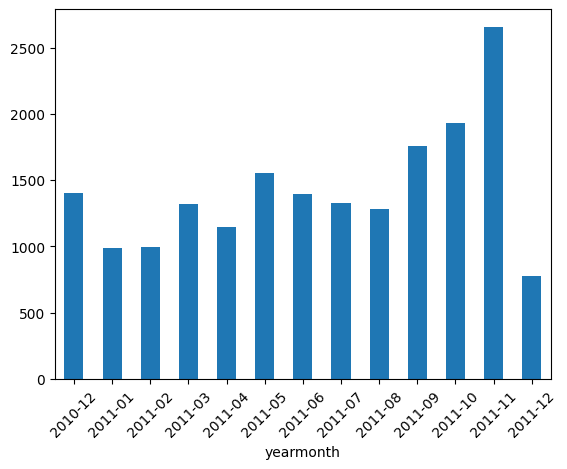

In [39]:
df_new.groupby('yearmonth')['invoiceno'].nunique().plot(
    kind='bar', rot=45
)

18.Побудуйте стовпчастий графік кількості унікальних інвойсів для топ 10 клієнтів за цим показником.

<Axes: xlabel='custid'>

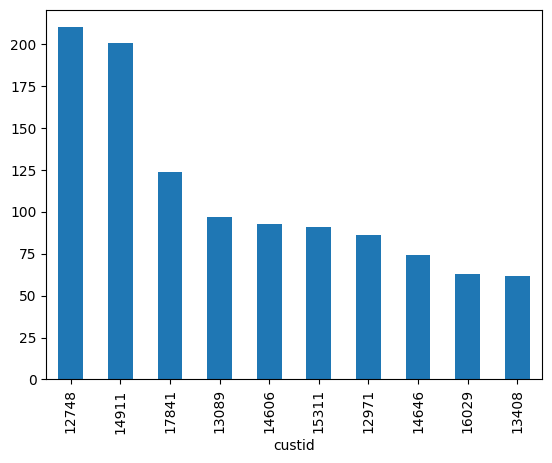

In [41]:
df_new.groupby('custid')['invoiceno'].nunique().nlargest(10).plot(
    kind='bar'
)

19.Створіть новий датафрейм, що містить сумарний `amountspent` по кожному ідентифікатору клієнта.

In [43]:
customer_spent = (
    df_new.groupby('custid', as_index=False)['amountspent']
    .sum()
    .set_index('custid')
)

20.Використовуючи датафрейм з попереднього пункту, виведіть, якими є 10, 25, 50, 75 і 90 персентилі сумарних витрат клієнтів за розглянутий період:

In [44]:
customer_spent.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])

,amountspent
count,4339.000000
mean,2053.793018
std,8988.248381
min,0.000000
10%,156.566000
25%,307.245000
50%,674.450000
75%,1661.640000
90%,3646.164000
max,280206.020000


21.Скільки унікальних клієнтів мають сумарні витрати вищі, ніж 90-тий персентиль в попередньому завдані?

In [45]:
p90 = customer_spent['amountspent'].quantile(0.90)
(customer_spent['amountspent'] > p90).sum()

np.int64(434)

22.Виведіть середню суму покупок в мережі по дням тижня. Дні тижня мають йти в звичному порядку Monday, Tuesday і т.д.

In [46]:
df_new.groupby(df_new['invoicedate'].dt.day_name())['amountspent'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

,amountspent
invoicedate,
Monday,21.065755
Tuesday,25.582686
Wednesday,23.056790
Thursday,24.694687
Friday,27.098468
Saturday,NaN
Sunday,12.624679


## Дослідимо продажі на суму 0 умовних одиниць

23.Можна було помітити вище, що в нас є продажі на суму 0. Дослідимо їх. Створіть новий датафрейм з тільки такими продажами.

In [47]:
zero_sales = df_new[df_new['amountspent'] == 0]

### Динаміка продажів на суму 0

24.Зобразіть у вигляді стовпчастої діаграми помісячну динаміку продажів на суму 0.

<Axes: title={'center': 'Frequency for different Months (Dec 2010 - Dec 2011)'}, xlabel='yearmonth'>

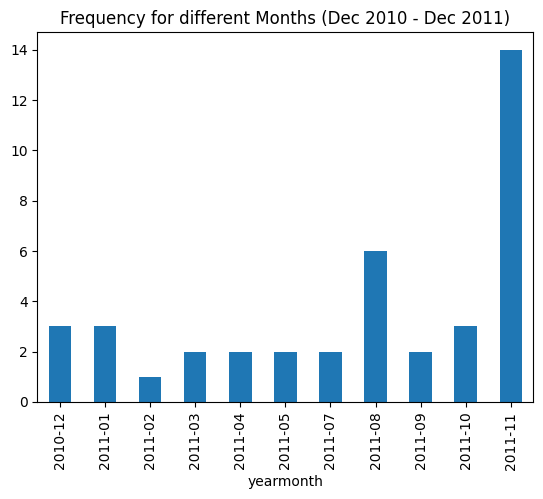

In [48]:
zero_sales.groupby('yearmonth').size().plot(
    kind='bar', title='Frequency for different Months (Dec 2010 - Dec 2011)'
)

25.Згрупуйте дані за країнами та підрахуйте кількість унікальних інвойсів з сумою 0 для кожної країни. Виведіть у вигляді датафрейму.

In [50]:
zero_sales.groupby('country')['invoiceno'].nunique().sort_values(
    ascending=False
).reset_index(name='num_orders')

,country,num_orders
0,United Kingdom,21
1,Australia,3
2,EIRE,2
3,Germany,2
4,Netherlands,1
5,France,1
6,Norway,1
7,RSA,1
8,Spain,1
9,Switzerland,1


Велике питання, чого магазин так багато порівняно роздавав безкоштовних товарів в UK, але така політика фірми :)

Якщо у вас ще є натхнення, пропоную задати до цих даних ще 3 своїх питання.

**1. Які 5 найпопулярніших товарів за загальною кількістю проданих одиниць (quantity)?**

In [51]:
df_new.groupby('description')['quantity'].sum().nlargest(5)

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
JUMBO BAG RED RETROSPOT,46181
WHITE HANGING HEART T-LIGHT HOLDER,36725


**2. В які години дня покупці роблять найбільше замовлень (піки купівельної активності)?**

<Axes: title={'center': 'Кількість замовлень за годинами доби'}, xlabel='Година', ylabel='Кількість інвойсів'>

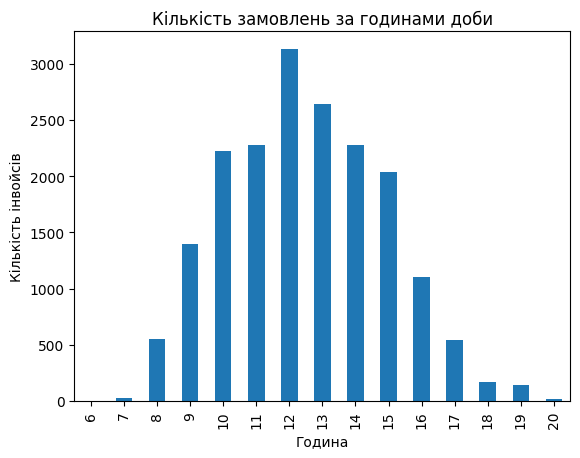

In [52]:
df_new.groupby('hour')['invoiceno'].nunique().plot(
    kind='bar',
    title='Кількість замовлень за годинами доби',
    xlabel='Година',
    ylabel='Кількість інвойсів',
)

**3. Яка частка (%) клієнтів є повторними (зробили 2 або більше унікальних замовлень)?**

In [53]:
orders_per_cust = df_new.groupby('custid')['invoiceno'].nunique()
repeat_pct = (orders_per_cust > 1).mean() * 100
print(f"Частка повторних клієнтів: {repeat_pct:.1f}%")

Частка повторних клієнтів: 65.6%
